IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from sklearn.model_selection import train_test_split
from statsmodels.stats.stattools import durbin_watson


LOAD THE DATA

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ikelfc/fredgraph/fredgraph.csv")
df.head()

,observation_date,UNRATE,CPIAUCSL
0,1947-01-01,NaN,21.48
1,1947-02-01,NaN,21.62
2,1947-03-01,NaN,22.00
3,1947-04-01,NaN,22.00
4,1947-05-01,NaN,21.95


Convert the date and time to pandas datetime

In [3]:
df["observation_date"] = pd.to_datetime(df["observation_date"])
df.head()

,observation_date,UNRATE,CPIAUCSL
0,1947-01-01,NaN,21.48
1,1947-02-01,NaN,21.62
2,1947-03-01,NaN,22.00
3,1947-04-01,NaN,22.00
4,1947-05-01,NaN,21.95


Information about the dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  948 non-null    datetime64[ns]
 1   UNRATE            935 non-null    float64       
 2   CPIAUCSL          947 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 22.3 KB


Total null values

In [5]:
df.isnull().sum()

observation_date     0
UNRATE              13
CPIAUCSL             1
dtype: int64

New dataframe with dropped missing values

In [6]:
df = df.copy()
df = df.dropna()
df_new = np.round(df,2)
df_new

,observation_date,UNRATE,CPIAUCSL
12,1948-01-01,3.4,23.68
13,1948-02-01,3.8,23.67
14,1948-03-01,4.0,23.50
15,1948-04-01,3.9,23.82
16,1948-05-01,3.5,24.01
...,...,...,...
942,2025-07-01,4.3,322.13
943,2025-08-01,4.3,323.36
944,2025-09-01,4.4,324.37
946,2025-11-01,4.5,325.03


Summary Statistics

Philips type

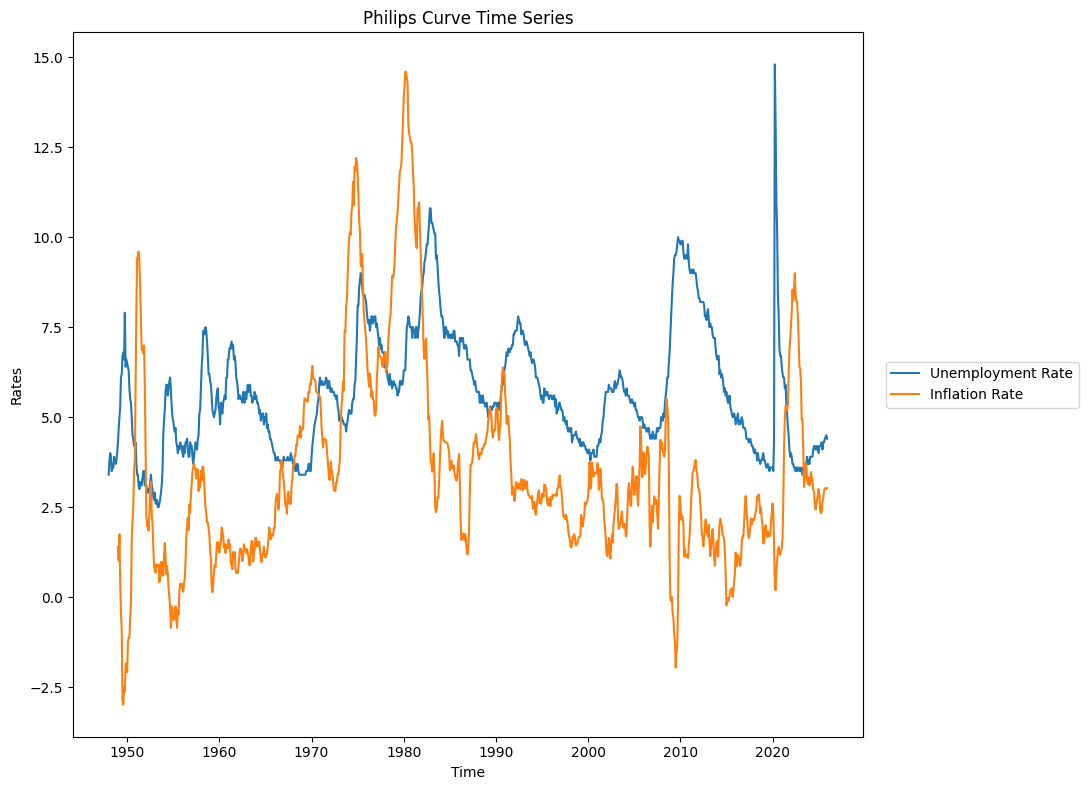

In [7]:
df_new["Inflation_rate"] = df_new["CPIAUCSL"].pct_change(12)*100

plt.figure(figsize=(11,8))
plt.plot(df_new["observation_date"],df_new["UNRATE"],label="Unemployment Rate")
plt.plot(df_new["observation_date"],df_new["Inflation_rate"],label= "Inflation Rate")

plt.title("Philips Curve Time Series")
plt.xlabel("Time")
plt.ylabel("Rates")
plt.legend(bbox_to_anchor=(1.02,0.5),loc="center left")
plt.tight_layout()
plt.show()

In [8]:
df_update = df_new[["UNRATE","Inflation_rate"]].dropna()

x = df_update[["UNRATE"]]
y = df_update["Inflation_rate"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model1 = LinearRegression()
model1.fit(x_train,y_train)

B0,B1 = model1.intercept_,model1.coef_[0]
print("B0:",B0)
print("B1:",B1)

B0: 2.8886114394722
B1: 0.09127725851560811


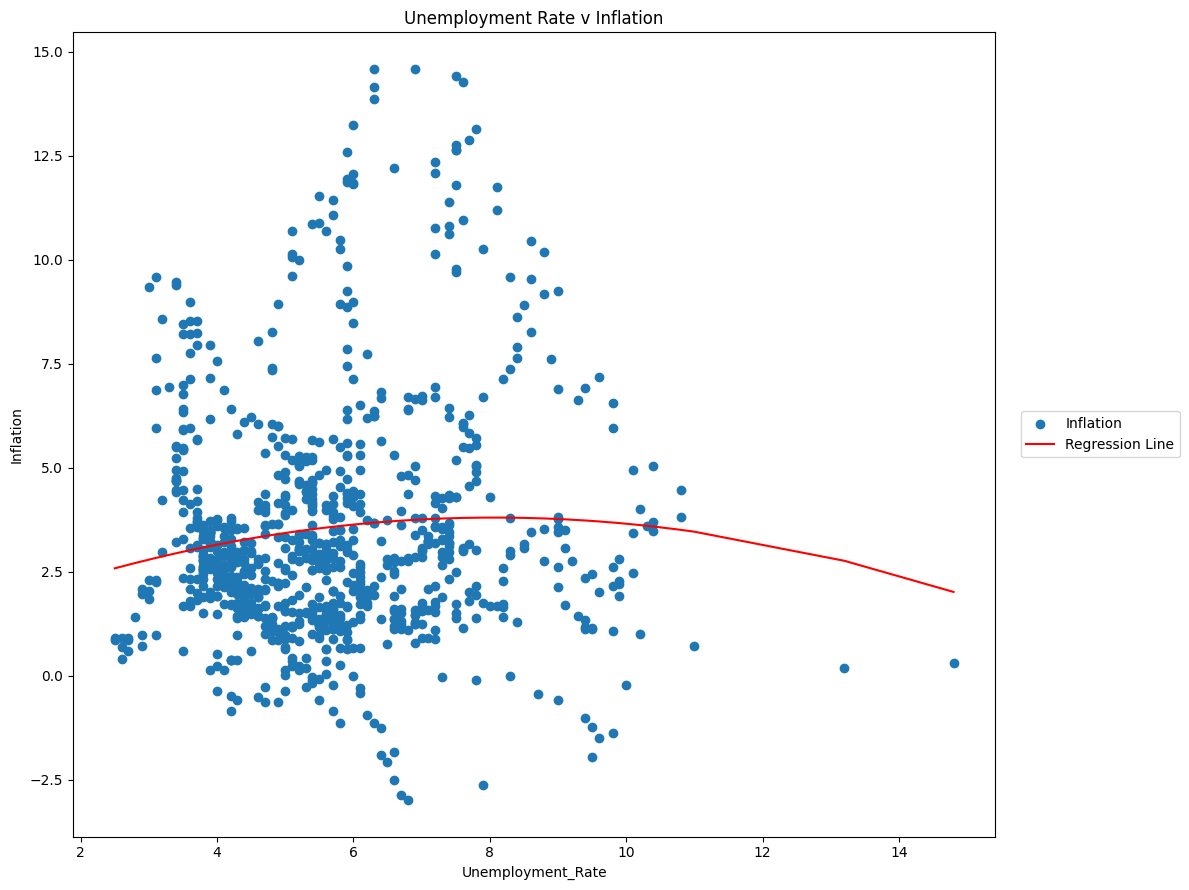

In [9]:
m2,m1,b = np.polyfit(df_update["UNRATE"],df_update["Inflation_rate"],2)
df_update["reg_model"] = m2 * (df_update["UNRATE"]**2) + m1 * (df_update["UNRATE"]) + b
plt.figure(figsize=(12,9))
df_plot = df_update.sort_values(by="UNRATE")
plt.scatter(df_update["UNRATE"],df_update["Inflation_rate"],marker="o",label="Inflation")
plt.plot(df_plot["UNRATE"],df_plot["reg_model"],color="red",label="Regression Line")
plt.title("Unemployment Rate v Inflation")
plt.xlabel("Unemployment_Rate")
plt.ylabel("Inflation")
plt.legend(bbox_to_anchor=(1.02,0.5),loc="center left")
plt.tight_layout()
plt.show()

In [10]:
poly_reg = f"{b:.3f} + {m1:.3f}unrate + {m2:.3f}unrate**2"
poly_reg

'1.239 + 0.636unrate + -0.039unrate**2'

In [11]:
df_update["Residual"] = df_update["Inflation_rate"] - df_update["reg_model"]
df_update["Residual"]

24    -1.851154
25    -2.343225
26    -1.688531
27    -3.082347
28    -4.067833
         ...   
942   -0.514882
943   -0.306461
944   -0.250363
946   -0.301513
947   -0.246691
Name: Residual, Length: 923, dtype: float64

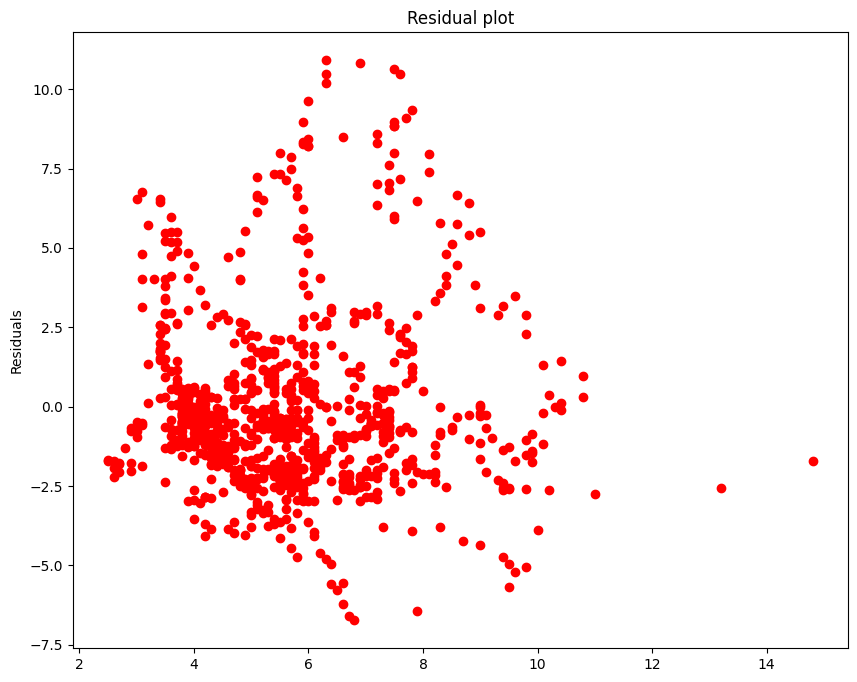

In [12]:
plt.figure(figsize=(10,8))
plt.title("Residual plot")
plt.ylabel("Residuals")
plt.scatter(df_update["UNRATE"],df_update["Residual"],color="red")
plt.show()

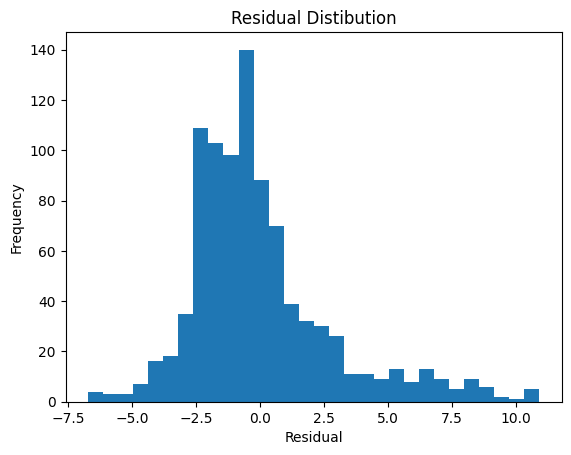

In [13]:
plt.hist(df_update["Residual"],bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distibution")
plt.show()

In [14]:
adfuller_result = adfuller(df_update["Inflation_rate"])

test_table = pd.DataFrame({
    "adf_stat" : [adfuller_result[0]],
    "adf_pval" : [adfuller_result[1]]
})
if test_table["adf_pval"].iloc[0] < 0.05:
    test_table["test"] = "Stationary"
else:
    test_table["test"] = "Non Stationary"
test_table.T

,0
adf_stat,-3.836404
adf_pval,0.002556
test,Stationary


In [15]:
model = VAR(df_update[["Inflation_rate", "UNRATE"]])
result = model.fit(maxlags=12,ic="aic")
result.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 01, Aug, 2026
Time:                     20:38:00
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -3.67287
Nobs:                     921.000    HQIC:                  -3.70527
Log likelihood:          -888.202    FPE:                  0.0241068
AIC:                     -3.72526    Det(Omega_mle):       0.0238472
--------------------------------------------------------------------
Results for equation Inflation_rate
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                     0.077305         0.045730            1.690           0.091
L1.Inflation_rate         1.399595         0.030509           45.875           0.000
L1.UNRATE                 0.003305 

In [16]:
test_causality = result.test_causality(caused="Inflation_rate",causing="UNRATE")
df3 = pd.DataFrame({"Test_statistic":[test_causality.test_statistic],
                    "p_value":[test_causality.pvalue]
                  })
if df3["p_value"].iloc[0] <= 0.05:
    df3["Theory"] = "Philips theory supports"
else:
    df3["Theory"] = "Philip[s theory does not support"
df3.T

,0
Test_statistic,0.153838
p_value,0.857422
Theory,Philip[s theory does not support


In [17]:
test_causality = result.test_causality(caused="UNRATE",causing="Inflation_rate")
df4 = pd.DataFrame({"Test_statistic":[test_causality.test_statistic],
                    "p_value":[test_causality.pvalue]
                  })
if df4["p_value"].iloc[0] <= 0.05:
    df4["Theory"] = "Philips theory supports"
else:
    df4["Theory"] = "Philip[s theory does not support"
df4.T

,0
Test_statistic,7.502522
p_value,0.000569
Theory,Philips theory supports


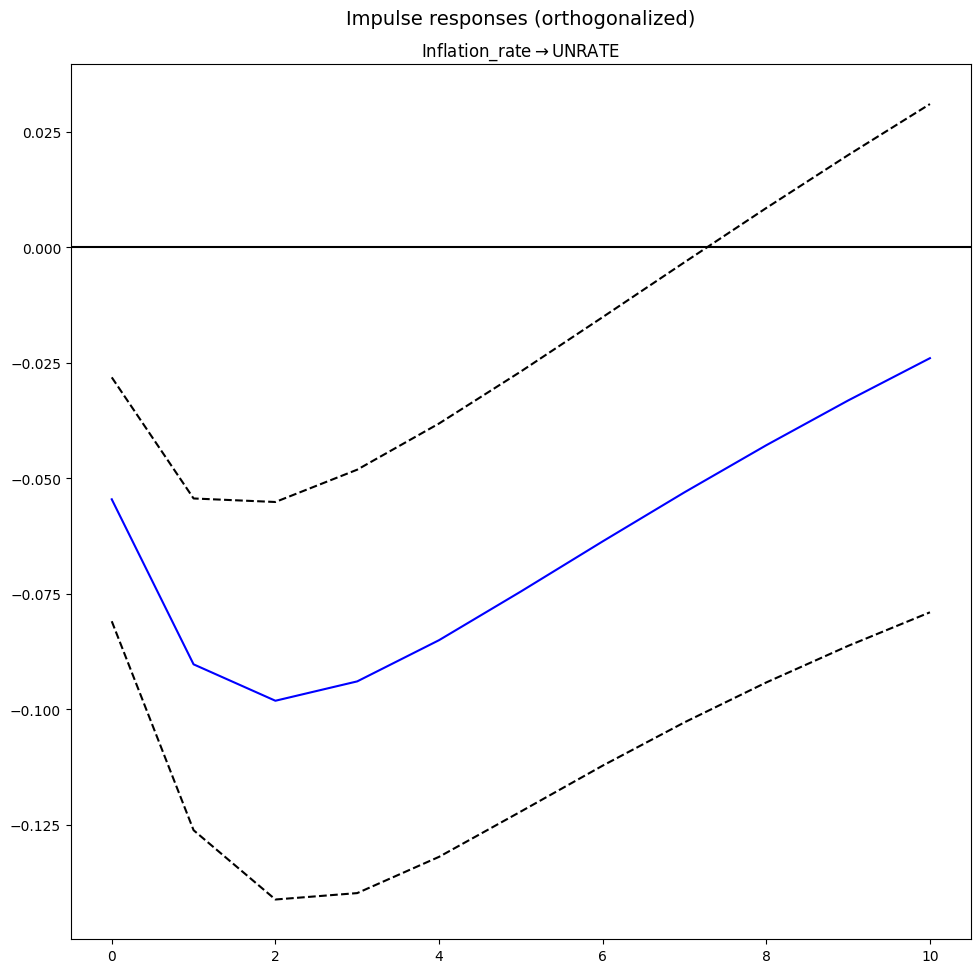

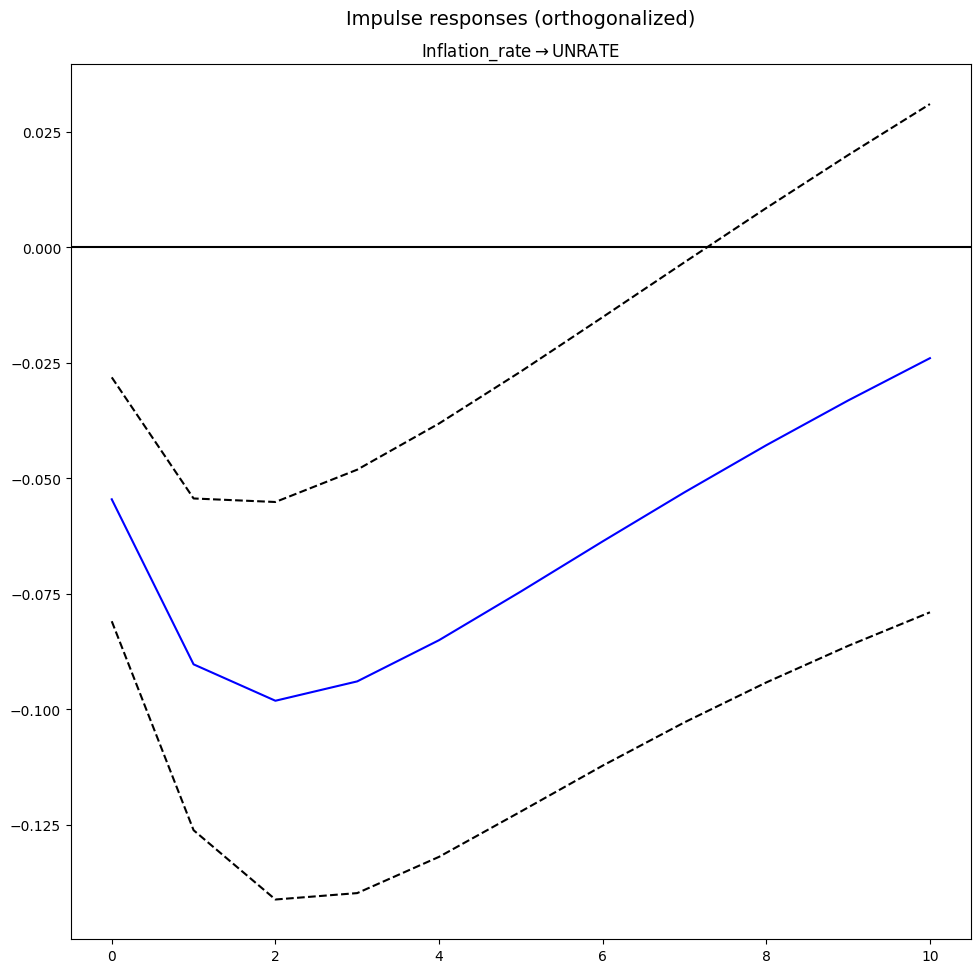

In [18]:
irf = result.irf(10)
irf.plot(orth=True,response="UNRATE",impulse="Inflation_rate")

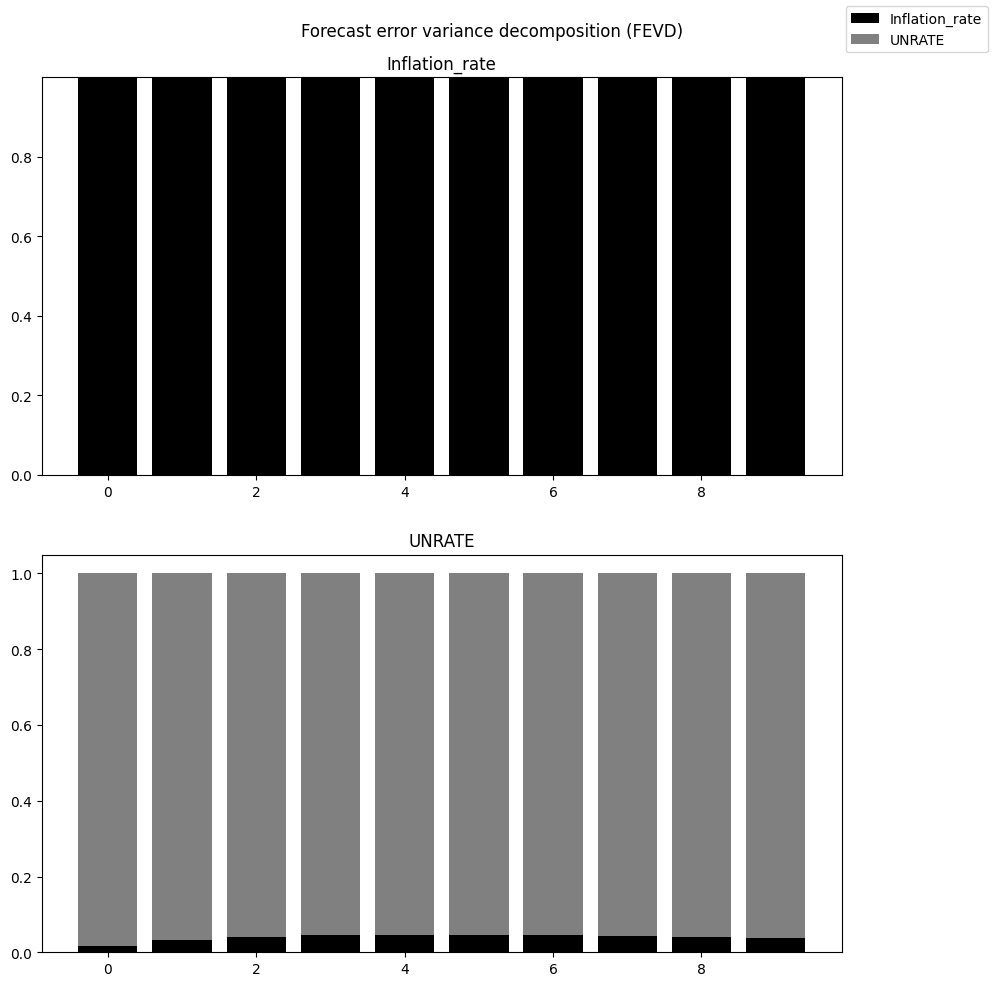

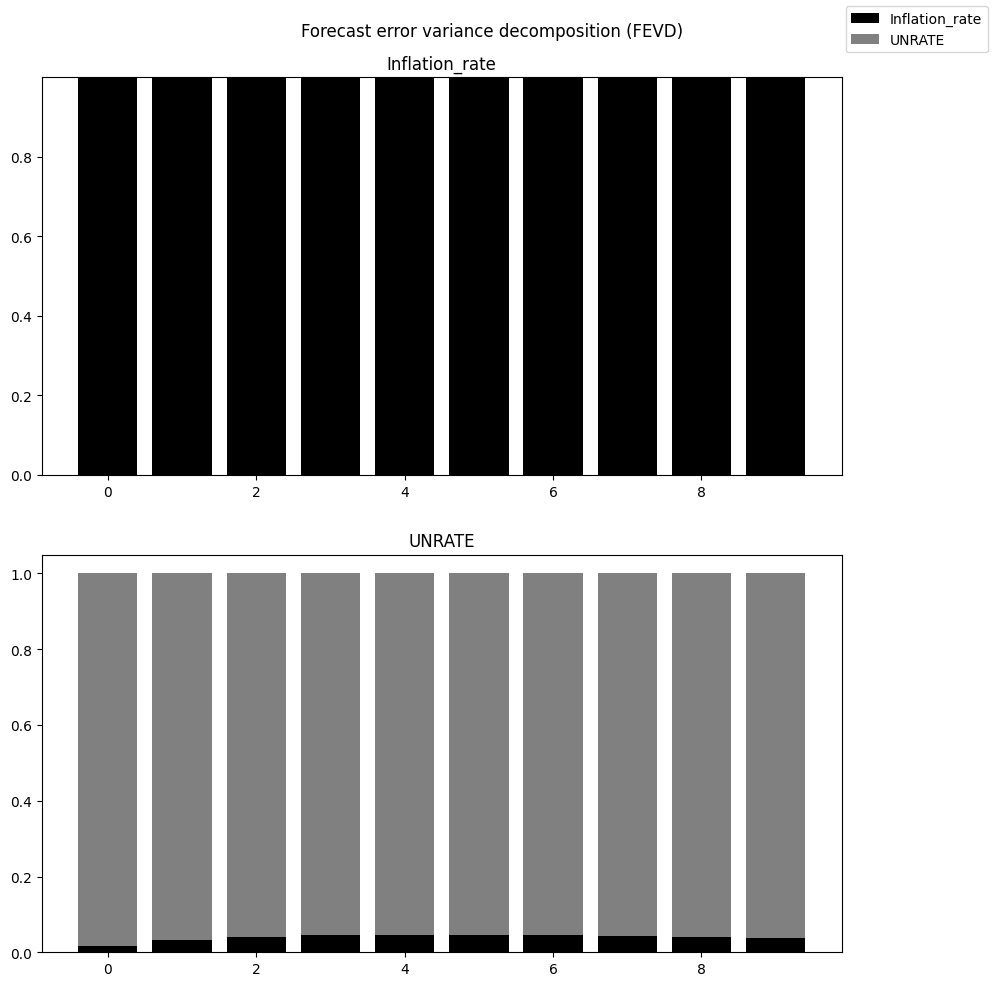

In [19]:
fevd = result.fevd(10)
fevd.plot()

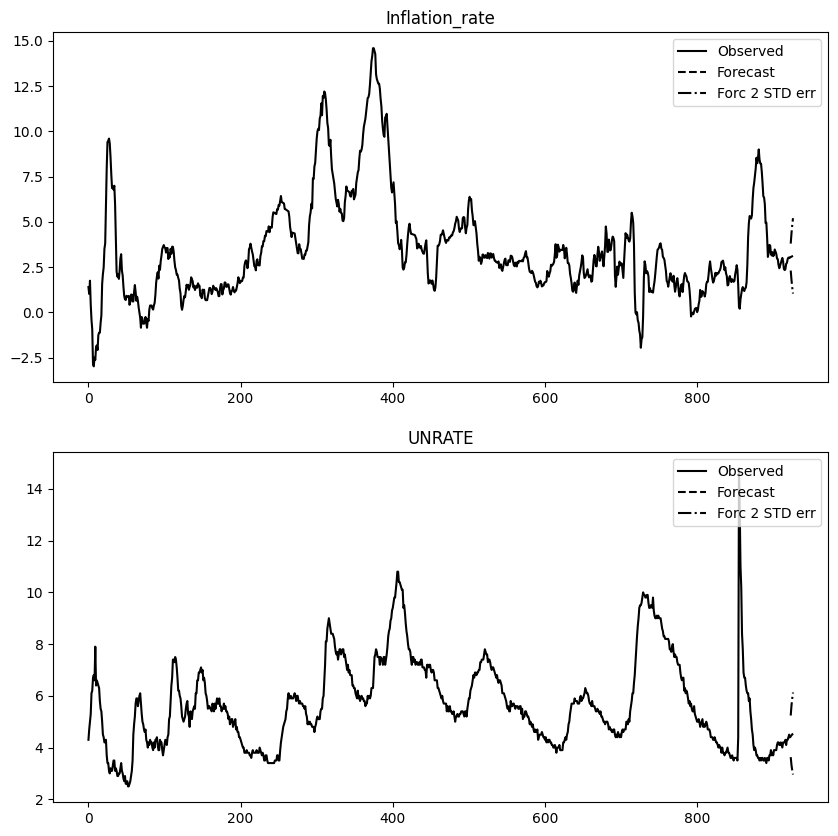

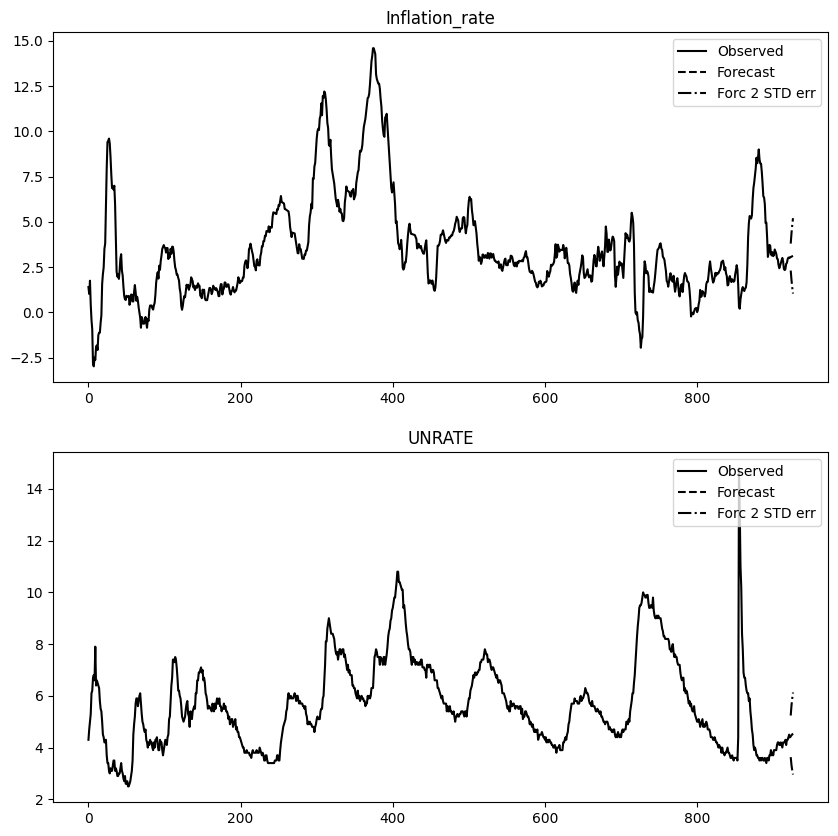

In [20]:
lag = result.k_ar
forecat = result.endog[-lag:]
result.plot_forecast(steps=4)

In [21]:
test = durbin_watson(result.resid)
unrate_test,inflation_test = test
results = pd.DataFrame({"Unrate ":[unrate_test],"Inflation":inflation_test})
results.T

,0
Unrate,2.015513
Inflation,2.001766


In [22]:
normality = result.test_normality()
print(normality.summary())

normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     6.857e+06          9.488   0.000  4
----------------------------------------
